# Proyecto GestoVoz 
Prof. Adan Hirales
Equipo: 
- Christofer Castaneda
- Ivan Mijares
- Alexander Orduna

# Librerias y Ruta 

In [1]:
# solo en caso de EMERGENCIAs descomentar
import sys
!{sys.executable} -m pip install \
    "numpy==1.26.4" \
    "opencv-python==4.8.1.78" \
    "mediapipe==0.10.9" \
    "seaborn" \
    "scikit-learn==1.5.1" \
    "coremltools" \
    --force-reinstall

import cv2
import mediapipe as mp
import numpy as np
import joblib
import json
import time
from pathlib import Path
from tqdm import tqdm
import coremltools as ct
from sklearn.metrics import recall_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Gestos
GESTURE_MAP = {
    "call"   : 0,
    "dislike": 1,
    "fist"   : 2,
    "like"   : 3,
    "ok"     : 4,
    "one"    : 5,
    "palm"   : 6,   # cuidado (alerta, necesita un recall critico >= 0.90)
    "peace"  : 7,
    "rock"   : 8,
}

LABEL_NAMES = list(GESTURE_MAP.keys())
N_CLASSES   = len(GESTURE_MAP)
N_LANDMARKS = 21
N_COORDS    = 2
N_FEATURES  = N_LANDMARKS * N_COORDS

# Umbrales MVP para poder migrarlo
MVP_F1_MACRO     = 0.88
MVP_ACCURACY     = 0.90
MVP_ALERT_RECALL = 0.90
ALERT_CLASS      = 6

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pygam 0.12.0 requires scipy<1.17,>=1.11.1, but you have scipy 1.17.1 which is incompatible.


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached mediapipe-0.10.9-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.5.1-cp311-cp311-win_amd64.whl.metadata (12 kB)
  Using cached coremltools-9.0-py3-none-any.whl
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)


Torch version 2.10.0+cpu has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLComputePlanProxy: No module named 'coremltools.libcoremlpython'
Fail to import BlobReader from libmilstoragepython. No module named 'coremltools.libmilstoragepython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelAssetProxy: No module named 'coremltools.libcoremlpython'
Fail to import BlobWriter from libmilstoragepython. No module named 'coremlto

In [2]:
HAGRID_ROOT = Path(r"D:\hagrid_normalized")
CACHE_DIR   = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

CACHE_X    = CACHE_DIR / "X_landmarks.npy"
CACHE_Y    = CACHE_DIR / "y_labels.npy"
MODEL_PATH = "gestovoz_rf.pkl"
META_PATH  = "gestovoz_metadata.json"

print("Debug de direccion, clases y features")
print(f"Dataset    : {HAGRID_ROOT}")
print(f"Clases     : {N_CLASSES}")
print(f"Features   : {N_FEATURES}")
print(f"\n   Mapeo de gestos:")
for name, idx in GESTURE_MAP.items():
    print(f"     [{idx}] {name}")

Debug de direccion, clases y features
Dataset    : D:\hagrid_normalized
Clases     : 9
Features   : 42

   Mapeo de gestos:
     [0] call
     [1] dislike
     [2] fist
     [3] like
     [4] ok
     [5] one
     [6] palm
     [7] peace
     [8] rock


# Extraccion de features

Para cada imagen del data set de HaGRID:
  1. Detectar la mano con MediaPipe Hands
  2. Extraer 21 landmarks (x, y, z)
  3. Normalizar relativo a la muneca (landmark 0)
  4. Guardar vector de 63 floats + etiqueta

Si ya existe el cache, se salta la extraccion automaticamente.

In [3]:
mp_hands   = mp.solutions.hands
EXTENSIONS = {".jpg", ".jpeg", ".png"}


def normalize_landmarks_xy(hand_landmarks) -> list[float]:
    # Extrae x, y de los 21 landmarks y normaliza relativo a la muneca.
    raw_x = [lm.x for lm in hand_landmarks.landmark]
    raw_y = [lm.y for lm in hand_landmarks.landmark]

    wx, wy = raw_x[0], raw_y[0]   # muneca = landmark 0

    normalized = []
    for x, y in zip(raw_x, raw_y):
        normalized.append(x - wx)
        normalized.append(y - wy)

    return normalized   # 42 floats


#### Extraer el dataset
Recorre hagrid_root/gesto/*.jpg y extrae los landmarks.
- hagrid_root- carpeta raiz (Hagrid) con subcarpetas por gesto (8 carpetas)
- gesture_map- dict nombre_gesto -> int label
- max_per_class- limite de imagenes por clase (None = todas)
- min_detection_confidence- La minima 

In [4]:
def extract_dataset(hagrid_root: Path,
                    gesture_map: dict,
                    max_per_class: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []

    with mp_hands.Hands(static_image_mode= True, max_num_hands= 1,min_detection_confidence = 0.50,) as hands:

        for gesture_name, label in gesture_map.items():
            gesture_dir = hagrid_root / gesture_name

            images = sorted([
                p for p in gesture_dir.iterdir()
                if p.suffix.lower() in EXTENSIONS
            ])
            if max_per_class:
                images = images[:max_per_class]

            detected, skipped = 0, 0

            for img_path in tqdm(images,
                                 desc=f"[{label}] {gesture_name:<8s}",
                                 unit="img"):
                img_bgr = cv2.imread(str(img_path))
                if img_bgr is None:
                    skipped += 1
                    continue

                result = hands.process(
                    cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                )

                if result.multi_hand_landmarks:
                    feats = normalize_landmarks_xy(result.multi_hand_landmarks[0])
                    X.append(feats)
                    y.append(label)
                    detected += 1
                else:
                    skipped += 1

            print(f"{detected:,} detectadas | {skipped:,} sin mano\n")

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [5]:
# si existe en el cache no se ejecuta
if CACHE_X.exists() and CACHE_Y.exists():
    print("Cache encontrado")
    X_data = np.load(CACHE_X)
    y_data = np.load(CACHE_Y)
    print(f"{X_data.shape[0]:,} muestras cargadas desde cache")
    for name, idx in GESTURE_MAP.items():
        count = np.sum(y_data == idx)
        print(f"[{idx}] {name:<8s}  {count:,} muestras")

else:
    print("Extrayendo landmarks \n")

    # para la demo se dejaron 5k imagenes por gesto
    # Para entrenamiento completo deja max_per_class=None
    X_data, y_data = extract_dataset(
        hagrid_root   = HAGRID_ROOT,
        gesture_map   = GESTURE_MAP,
        max_per_class = None,
    )

    np.save(CACHE_X, X_data)
    np.save(CACHE_Y, y_data)
    print(f"\n Cache guardado en '{CACHE_DIR}'")

# Resumen del dataset 
print(f"\n   Total muestras: {X_data.shape[0]:,}")
print(f"   Features: {X_data.shape[1]}")
print(f"\n   Muestras por clase:")
for name, idx in GESTURE_MAP.items():
    print(f"     [{idx}] {name:<8s}")

Cache encontrado
194,328 muestras cargadas desde cache
[0] call      14,936 muestras
[1] dislike   20,178 muestras
[2] fist      18,152 muestras
[3] like      19,296 muestras
[4] ok        26,094 muestras
[5] one       22,460 muestras
[6] palm      25,953 muestras
[7] peace     23,932 muestras
[8] rock      23,327 muestras

   Total muestras: 194,328
   Features: 42

   Muestras por clase:
     [0] call    
     [1] dislike 
     [2] fist    
     [3] like    
     [4] ok      
     [5] one     
     [6] palm    
     [7] peace   
     [8] rock    


# Train (80) / Test split (10) / Validation (10)

In [6]:
# Primer split: 80% train, 20% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_data,
)

# Segundo split: el 20% temporal → 10% test, 10% validacion
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size    = 0.50,
    random_state = 42,
    stratify     = y_temp,
)

print("Split 80 / 10 / 10 estratificado")
print(f"Train      : {len(X_train):,}  ({len(X_train)/len(X_data):.0%})")
print(f"Test       : {len(X_test):,}   ({len(X_test)/len(X_data):.0%})")
print(f"Validacion : {len(X_val):,}   ({len(X_val)/len(X_data):.0%})")

Split 80 / 10 / 10 estratificado
Train      : 155,462  (80%)
Test       : 19,433   (10%)
Validacion : 19,433   (10%)


# Entrenamiento

Hiperparametros justificados:
- n_estimators=200- mayor ensemble da una menor varianza
- max_features='sqrt'- diversidad entre arboles, estandar para clasificacion
- min_samples_leaf=2- evita hojas de 1 muestra (ruido)
- class_weight='balanced'- compensa clases con diferente cantidad de imagenes
- n_jobs=-1- usa todos los nucleos disponibles

In [7]:
#Para mi laptop
rf = RandomForestClassifier(
    n_estimators      = 300,
    max_features      = "sqrt",
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight      = "balanced",
    random_state      = 42,
    n_jobs            = -1,
)

print("Entrenando Random Forest")
t0 = time.time()
rf.fit(X_train, y_train)
t_train = time.time() - t0

print(f"Listo en {t_train:.1f}s")
print(f"   Arboles entrenados : {rf.n_estimators}")
print(f"   Clases detectadas  : {list(rf.classes_)}")

Entrenando Random Forest
Listo en 47.5s
   Arboles entrenados : 300
   Clases detectadas  : [0, 1, 2, 3, 4, 5, 6, 7, 8]


# Evaluacion

F1-Score Macro : 0.8591   (umbral >= 0.88)
Accuracy       : 0.8639   (umbral >= 0.9)
Recall alerta  : 0.9079   (umbral >= 0.9)

  F1 por gesto:
    [0] call      0.7995  ███████████████████████
    [1] dislike   0.8621  █████████████████████████
    [2] fist      0.8424  █████████████████████████
    [3] like      0.8193  ████████████████████████
    [4] ok        0.9107  ███████████████████████████
    [5] one       0.8102  ████████████████████████
    [6] palm      0.9218  ███████████████████████████ ← ALERTA
    [7] peace     0.8808  ██████████████████████████
    [8] rock      0.8855  ██████████████████████████

  Reporte completo:
              precision    recall  f1-score   support

        call       0.77      0.84      0.80      1493
     dislike       0.84      0.89      0.86      2018
        fist       0.82      0.86      0.84      1815
        like       0.79      0.85      0.82      1930
          ok       0.94      0.89      0.91      2610
         one       0.81      0.

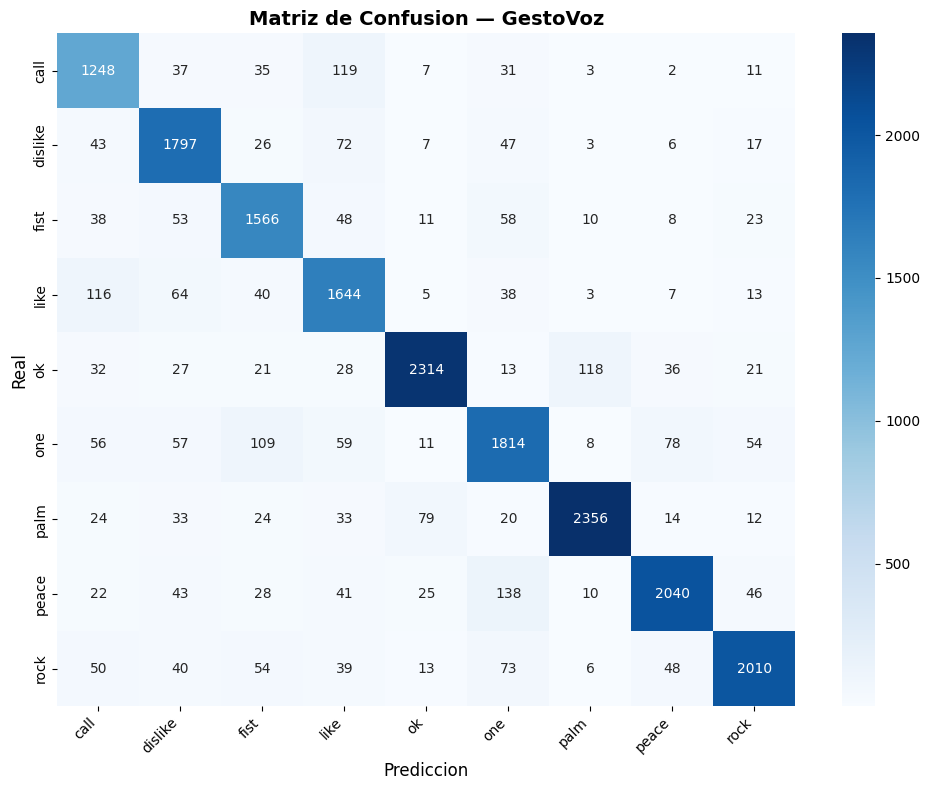

In [8]:
# Evaluacion 

y_pred = rf.predict(X_test)

f1_macro = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)
f1_per_class = f1_score(y_test, y_pred, average=None,labels=list(range(N_CLASSES)))
recall_per_class = recall_score(y_test, y_pred, average=None, labels=list(range(N_CLASSES)))
recall_alert = recall_per_class[ALERT_CLASS]

# Debug para ver como sale el entrenamiento
print(f"F1-Score Macro : {f1_macro:.4f}   (umbral >= {MVP_F1_MACRO})")
print(f"Accuracy       : {acc:.4f}   (umbral >= {MVP_ACCURACY})")
print(f"Recall alerta  : {recall_alert:.4f}   (umbral >= {MVP_ALERT_RECALL})")
print("\n  F1 por gesto:")
for name, idx in GESTURE_MAP.items():
    bar    = "█" * int(f1_per_class[idx] * 30)
    alert  = " ← ALERTA" if idx == ALERT_CLASS else ""
    print(f"    [{idx}] {name:<8s}  {f1_per_class[idx]:.4f}  {bar}{alert}")

print("\n  Reporte completo:")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

# Matriz de confusion 
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=ax,
)
ax.set_xlabel("Prediccion", fontsize=12)
ax.set_ylabel("Real",       fontsize=12)
ax.set_title("Matriz de Confusion — GestoVoz", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

#### Validacion

In [9]:
# ── Evaluacion en validacion ──────────────────────────────────────────────────
y_val_pred   = rf.predict(X_val)
f1_val       = f1_score(y_val, y_val_pred, average="macro")
acc_val      = accuracy_score(y_val, y_val_pred)

print("  VALIDACION (conjunto separado, nunca visto en entrenamiento)")
print(f"  F1-Score Macro : {f1_val:.4f}")
print(f"  Accuracy       : {acc_val:.4f}")

# Comparacion test vs validacion — diferencias grandes indican overfitting
diff_f1  = abs(f1_macro - f1_val)
diff_acc = abs(acc - acc_val)
print(f"\n  Diferencia test vs val:")
print(f"    F1-Score : {diff_f1:.4f}  {'estable' if diff_f1 < 0.03 else 'revisar overfitting'}")
print(f"    Accuracy : {diff_acc:.4f}  {'estable' if diff_acc < 0.03 else 'revisar overfitting'}")

  VALIDACION (conjunto separado, nunca visto en entrenamiento)
  F1-Score Macro : 0.8556
  Accuracy       : 0.8608

  Diferencia test vs val:
    F1-Score : 0.0036  estable
    Accuracy : 0.0032  estable


# Guardar modelo

In [ ]:
import copy
from coremltools.models.datatypes import Array

# ── Guardar .pkl completo (modelo original intacto) ───────────────────────────
joblib.dump(rf, MODEL_PATH)
print(f"Modelo .pkl guardado : {MODEL_PATH}")

# ── Crear version lite para CoreML (50 arboles en vez de 300) ─────────────────
# No reentrenamos — solo tomamos los primeros 50 estimators del RF ya entrenado
N_TREES_COREML = 50

rf_lite = copy.deepcopy(rf)
rf_lite.estimators_ = rf_lite.estimators_[:N_TREES_COREML]
rf_lite.n_estimators = N_TREES_COREML

print(f"\nRF lite: {N_TREES_COREML} arboles (de {rf.n_estimators} originales)")
print("Verificando accuracy del modelo lite...")

y_pred_lite = rf_lite.predict(X_test)
acc_lite    = accuracy_score(y_test, y_pred_lite)
f1_lite     = f1_score(y_test, y_pred_lite, average="macro")
print(f"  Accuracy lite : {acc_lite:.4f}  (original: {acc:.4f})")
print(f"  F1 Macro lite : {f1_lite:.4f}  (original: {f1_macro:.4f})")

# ── Convertir RF lite a CoreML ────────────────────────────────────────────────
print("\nIniciando conversion a Core ML (modelo lite)...")
try:
    modelo_coreml = ct.converters.sklearn.convert(
        rf_lite,
        input_features       = [("landmarks_42", Array(N_FEATURES))],
        output_feature_names = "gesto_predicho",
    )

    modelo_coreml.author            = "Christofer Castaneda, Ivan Mijares, Alexander Orduna"
    modelo_coreml.license           = "Computo Ubicuo — CETYS Universidad"
    modelo_coreml.version           = "1.0-lite"
    modelo_coreml.short_description = (
        f"GestoVoz RF lite ({N_TREES_COREML} trees) — {N_CLASSES} gestos. "
        f"Input: 42 floats (21 landmarks xy normalizados). "
        f"F1 Macro: {round(f1_lite,4)} | Accuracy: {round(acc_lite,4)}"
    )

    MLMODEL_PATH = MODEL_PATH.replace(".pkl", ".mlmodel")
    modelo_coreml.save(MLMODEL_PATH)
    print(f"Modelo CoreML guardado: {MLMODEL_PATH}")

except Exception as e:
    print(f"Error: {e}")

: 